# Skin Lesion Image Preprocessing for ResNet-50

This notebook resizes a folder of JPG images to **224×224 PNG** files suitable for ResNet-50.

**Pipeline per image:**
1. Load JPG and apply EXIF orientation (important for phone photos).
2. Convert to RGB.
3. Scale down preserving aspect ratio (LANCZOS resampling).
4. Pad with black borders to reach exactly 224×224.
5. Save as PNG.


## 1. Imports

In [1]:
from pathlib import Path
from PIL import Image, ImageOps

## 2. Configuration

Adjust paths and target size here. The output directory is created automatically if it doesn't exist.

In [ ]:
INPUT_DIR = Path("Data/images")
OUTPUT_DIR = Path("Data/images_resized")

TARGET_SIZE = (224, 224)
PAD_COLOR = (0, 0, 0)  # black

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Input  : {INPUT_DIR.resolve()}")
print(f"Output : {OUTPUT_DIR.resolve()}")

Input  : E:\arman\Homework\Machine Learning and AI in Living Organisms\Research-Project\Data\images
Output : E:\arman\Homework\Machine Learning and AI in Living Organisms\Research-Project\Data\images_resized


## 3. Discover input files

Find every `.jpg` / `.jpeg` (case-insensitive) in the input directory.

In [3]:
jpg_files = sorted(
    p for p in INPUT_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in {".jpg", ".jpeg"}
)

print(f"Found {len(jpg_files)} image(s).")
for p in jpg_files[:5]:
    print(f"  {p.name}")
if len(jpg_files) > 5:
    print(f"  ... and {len(jpg_files) - 5} more")

Found 1616 image(s).
  ISIC_0079358.jpg
  ISIC_0086914.jpg
  ISIC_0088904.jpg
  ISIC_0094098.jpg
  ISIC_0095134.jpg
  ... and 1611 more


## 4. Resize-with-padding function

Scales the image down so its longest side equals 224, then centers it on a black 224×224 canvas. This preserves the lesion's true aspect ratio (no stretching, no cropping).

In [4]:
def resize_with_padding(img, target_size=TARGET_SIZE, pad_color=PAD_COLOR):
    """Resize to fit inside target_size (preserving aspect ratio), then pad to exact size."""
    if img.mode != "RGB":
        img = img.convert("RGB")

    # Scale down preserving aspect ratio. LANCZOS is the high-quality default for downsampling.
    fitted = ImageOps.contain(img, target_size, method=Image.Resampling.LANCZOS)

    # Center on a black canvas of exactly target_size.
    canvas = Image.new("RGB", target_size, pad_color)
    offset = ((target_size[0] - fitted.width) // 2,
              (target_size[1] - fitted.height) // 2)
    canvas.paste(fitted, offset)
    return canvas

## 5. Sanity check on one image

Preview the result of the pipeline on the first image before processing the whole batch.

Sample        : ISIC_0079358.jpg
Original size : 1920 x 1080
Processed size: 224 x 224


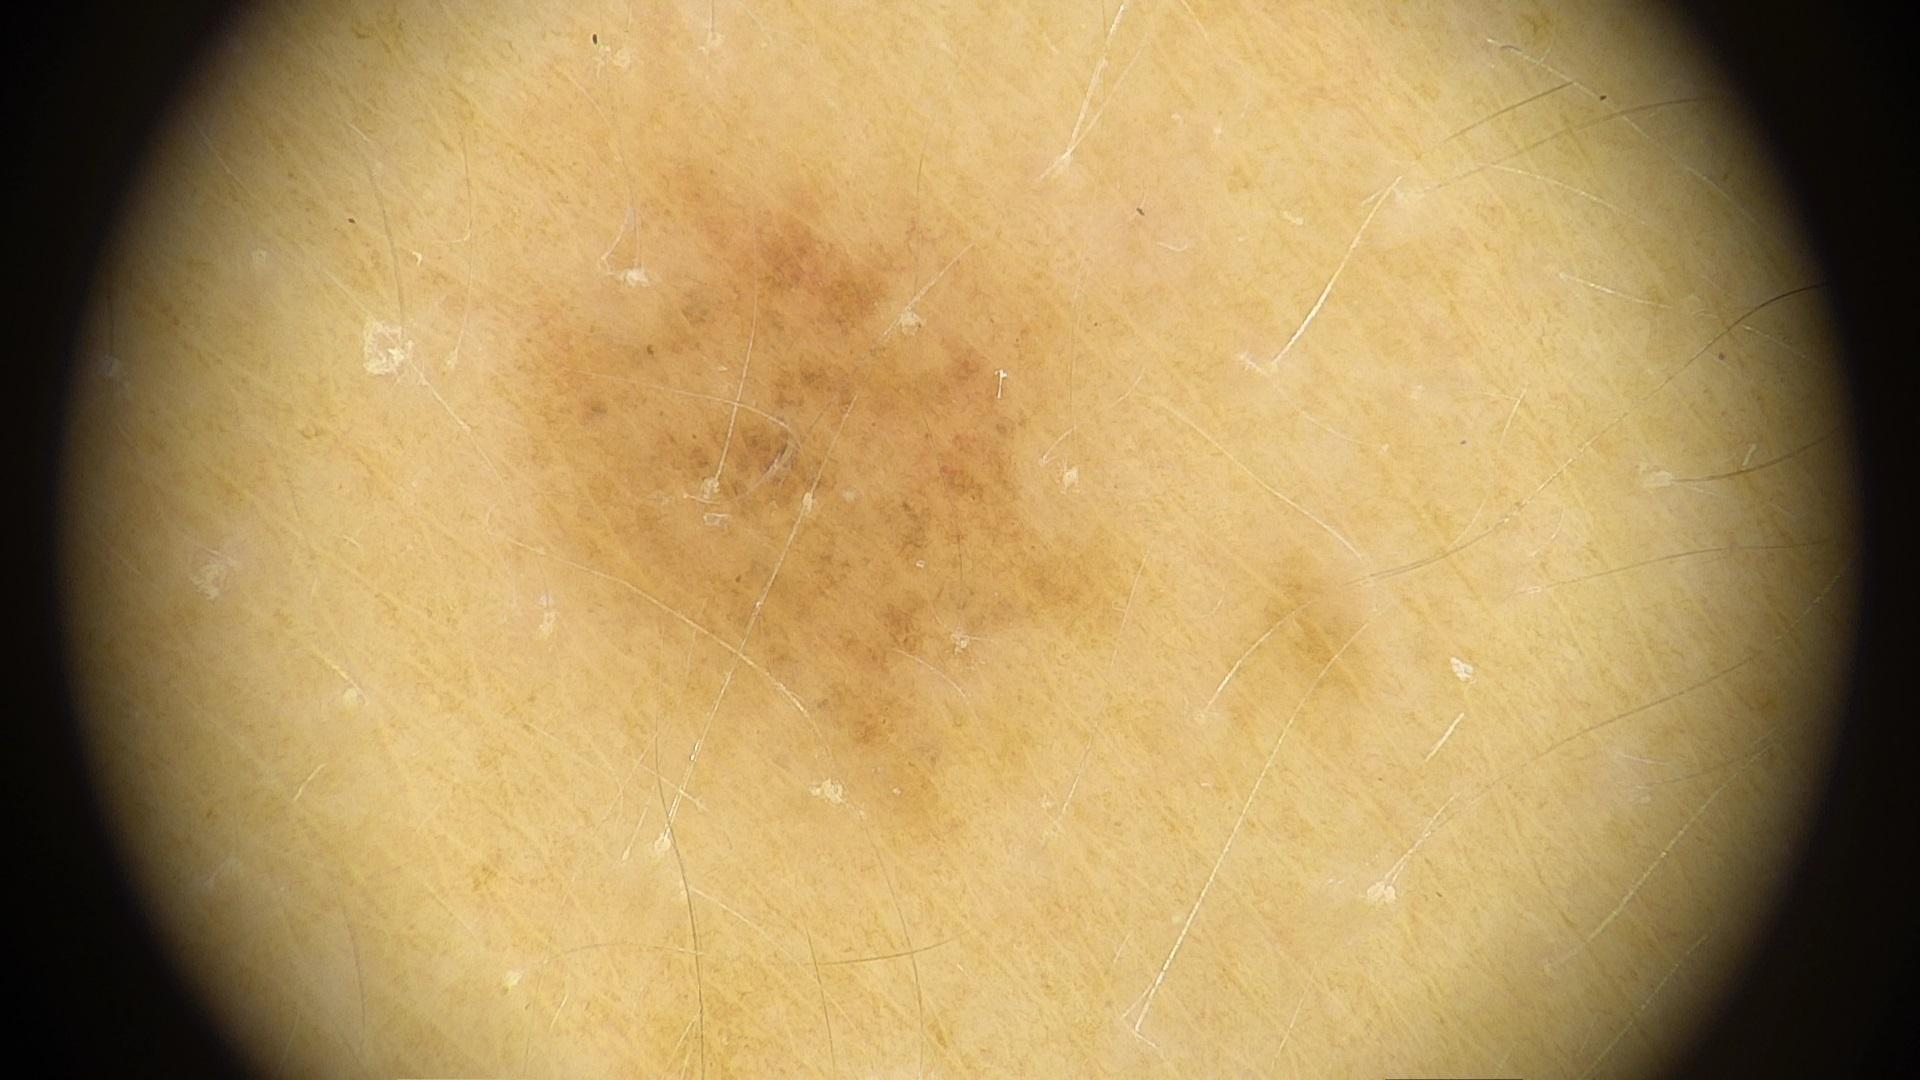

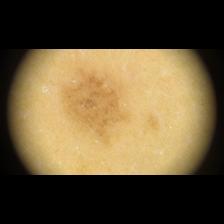

In [6]:
if jpg_files:
    sample_path = jpg_files[0]
    with Image.open(sample_path) as img:
        img = ImageOps.exif_transpose(img)
        original_size = img.size
        processed = resize_with_padding(img)

    print(f"Sample        : {sample_path.name}")
    print(f"Original size : {original_size[0]} x {original_size[1]}")
    print(f"Processed size: {processed.size[0]} x {processed.size[1]}")

    # Display in the notebook.
    display(img)
    display(processed)
else:
    print("No images to preview.")

## 6. Process the full batch

Convert every JPG to a 224×224 PNG in the output directory. Filenames are preserved (just with a `.png` extension).

In [7]:
successes, failures = 0, []

for src in jpg_files:
    dst = OUTPUT_DIR / (src.stem + ".png")
    try:
        with Image.open(src) as img:
            img = ImageOps.exif_transpose(img)  # respect phone-photo orientation
            processed = resize_with_padding(img)
            processed.save(dst, format="PNG", optimize=True)
        successes += 1
    except Exception as e:
        failures.append((src.name, str(e)))

print(f"Succeeded: {successes}")
print(f"Failed   : {len(failures)}")
for name, err in failures:
    print(f"  {name}: {err}")

Succeeded: 1616
Failed   : 0


## 7. Verify the output

Confirm every PNG in the output directory is exactly 224×224.

In [8]:
png_files = sorted(OUTPUT_DIR.glob("*.png"))
print(f"PNG files in output: {len(png_files)}")

bad = []
for p in png_files:
    with Image.open(p) as img:
        if img.size != TARGET_SIZE:
            bad.append((p.name, img.size))

if bad:
    print("Files NOT at target size:")
    for name, size in bad:
        print(f"  {name}: {size}")
else:
    print(f"All {len(png_files)} files are {TARGET_SIZE[0]}x{TARGET_SIZE[1]}.")

PNG files in output: 1616
All 1616 files are 224x224.
